In [1]:
# Run this in a Jupyter cell (with ! prefix) or in your Ubuntu terminal
!pip install torch torchvision opencv-python matplotlib requests transformers
!pip install git+https://github.com/facebookresearch/segment-anything.git

# Download the SAM ViT-B model weights (lighter and faster for exploration)
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

  Using cached opencv_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached regex-2026.7.19-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached safetensors-0.8.0-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.2 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached opencv_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl (73.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 47.6 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.2/793.2 kB 58.3 MB

Directory ready. Sample image saved at: input_images/sample_cat.jpg
Loading DINOv2 model from Hugging Face...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model loaded successfully.


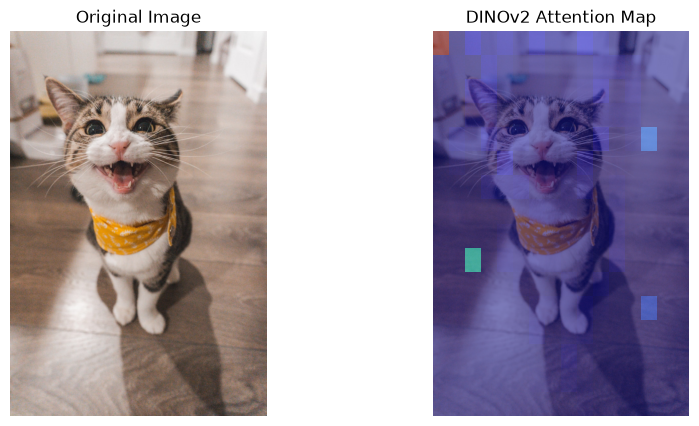

Result saved to: output_images/01_dino_attention.png


In [3]:
# [Cell 1: Imports & Setup]
import os
import torch
import requests
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoImageProcessor, AutoModel

# Create directories for inputs and outputs
os.makedirs("input_images", exist_ok=True)
os.makedirs("output_images", exist_ok=True)

# Download a sample image if it doesn't exist
sample_image_url = "https://images.unsplash.com/photo-1543852786-1cf6624b9987?q=80&w=800&auto=format&fit=crop"
sample_image_path = "input_images/sample_cat.jpg"

if not os.path.exists(sample_image_path):
    response = requests.get(sample_image_url)
    with open(sample_image_path, "wb") as file:
        file.write(response.content)

print(f"Directory ready. Sample image saved at: {sample_image_path}")

# [Cell 2: Load DINOv2 Model]
print("Loading DINOv2 model from Hugging Face...")
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
model = AutoModel.from_pretrained("facebook/dinov2-base", attn_implementation="eager")
model.eval()
print("Model loaded successfully.")

# [Cell 3: Extract & Visualize Attention]
# Load and preprocess the image
image = Image.open(sample_image_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt")

# Forward pass with output_attentions=True
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

# DINOv2 outputs attentions for each layer. We take the last layer.
# Shape: (batch_size, num_heads, sequence_length, sequence_length)
attentions = outputs.attentions[-1]
num_heads = attentions.shape[1]

# The first token is the CLS token. We want the attention of the CLS token to all other patches.
# Sequence length is (H_patches * W_patches) + 1 (for CLS)
cls_attention = attentions[0, :, 0, 1:] 

# Average the attention across all heads
mean_attention = cls_attention.mean(dim=0)

# Reshape the flat sequence back into a 2D grid (patch size is 14x14)
patch_h = inputs["pixel_values"].shape[2] // 14
patch_w = inputs["pixel_values"].shape[3] // 14
attention_map = mean_attention.reshape(patch_h, patch_w).numpy()

# Plot and save
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image)
# Overlay the attention map, resizing it to the original image shape
plt.imshow(attention_map, cmap="jet", alpha=0.5, extent=(0, image.size[0], image.size[1], 0))
plt.title("DINOv2 Attention Map")
plt.axis("off")

output_path = "output_images/01_dino_attention.png"
plt.savefig(output_path, bbox_inches="tight")
plt.show()
print(f"Result saved to: {output_path}")